Clone the repo with data and dataloaders

In [52]:
!git clone https://github.com/darreld081/cis6270-project-1.git

fatal: destination path 'cis6270-project-1' already exists and is not an empty directory.


Project imports and variables

In [53]:
!pip install lightning

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from pathlib import Path

In [ ]:
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 2e-4
BASE_CHANNELS = 32
SAMPLE_STEPS = 100
SAMPLE_DIM = 50
SEED = 7
TRAIN_TEST_SPLIT = [0.8, 0.2]
OUTPUT_DIR = Path("flow_matching_output")
SAMPLES_TO_PLOT = 16
NUM_CLASSES = 3          # leiden_Trametinib_5.0uM clusters '1.0','3.0','5.0'
NULL_CLASS_IDX = NUM_CLASSES   # reserved index for CFG's unconditional token
COND_EMBED_DIM = 8
P_UNCOND = 0.15           # fraction of batch labels dropped to NULL during training
GUIDANCE_SCALE = 2.0      # w in v_uncond + w*(v_cond - v_uncond); used at sampling time



In [56]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


Setup datamodule

In [57]:
import argparse
import sys
import pytorch_lightning as pl

# Add the path to your module to sys.path
sys.path.append("/content/cis6270-project-1/dataloaders")

# Import the class directly from your local file
from trametinib_loader import TrametinibSingleBranchDataModule

# 1. Define the configuration arguments expected by __init__
args = argparse.Namespace(
    batch_size=BATCH_SIZE,
    dim=SAMPLE_DIM,
    whiten=False,
    split_ratios=TRAIN_TEST_SPLIT,    # 80% train, 20% validation
    data_path="/content/cis6270-project-1/data/Trametinib_5.0uM_pca_and_leidenumap_labels.csv"      # Path to your local CSV file
)

# 2. Instantiate the DataModule (this triggers _prepare_data automatically)
print("Initializing DataModule...")
datamodule = TrametinibSingleBranchDataModule(args)

Initializing DataModule...


Extract dataloaders from data modules

In [ ]:
train_loader = datamodule.train_dataloader()
val_loader = datamodule.val_dataloader()
test_loader = datamodule.test_dataloader()

# 4. Verify batch shapes by iterating once
for batch in train_loader:
    # CombinedLoader yields a dictionary matching the keys defined in train_dataloader()
    train_samples = batch[0]["train_samples"]
    metric_samples = batch[0]["metric_samples"]

    # Extract x0 (DMSO/Control) and x1 (Trametinib/Treated)
    x0_data, x0_weights = train_samples[0]["x0"]
    x1_data, x1_labels = train_samples[0]["x1"]

    x0_data = x0_data.unsqueeze(1)
    x1_data = x1_data.unsqueeze(1)

    # Extract static evaluation clusters
    cluster_1 = metric_samples[0][0]
    cluster_0 = metric_samples[0][1]

    print("\n--- BATCH LOADED SUCCESSFULLY ---")
    print(f"x0 (DMSO) batch shape     : {x0_data.shape}")       # [batch_size, 50]
    print(f"x1 (Treated) batch shape  : {x1_data.shape}")       # [batch_size, 50]
    print(f"Metric Cluster 0 shape    : {cluster_0.shape}")
    print(f"Metric Cluster 1 shape    : {cluster_1.shape}")
    break

Create function for sampling noise based on the DMSO initial distribution (x0)

In [35]:
def sample_noise(num_samples: int):
  # 1. Extract full datasets directly from datamodule attributes
  x0_all = datamodule.coords_t0  # Shape: [N_samples, 50]

  # 2. Compute Mean & Covariance for x0 (DMSO)
  mean_x0 = x0_all.mean(dim=0)
  # Unbiased covariance matrix calculation (Shape: [50, 50])
  cov_x0 = torch.cov(x0_all.T)

  # 3. Create a Multivariate Normal Distribution
  dist_x0 = torch.distributions.MultivariateNormal(loc=mean_x0, covariance_matrix=cov_x0)

  # 4. Sample new synthetic cell (1 new cell representations)
  sample_x0 = dist_x0.sample((num_samples,))  # Shape: [num_samples, 50]
  sample_x0 = sample_x0.unsqueeze(1)  # Shape: [num_samples, 1, 50]

  return sample_x0

Test the noise sampling

In [37]:
sample = sample_noise(2)
print(sample)

tensor([[[-4.4495, -1.3865,  0.9397, -2.0551, -0.1476, -0.2020,  0.3606,
           0.2208,  1.4504,  0.7870, -0.8895,  0.7307,  0.1310,  0.2196,
           0.6659,  1.1616, -0.6085,  0.6491,  0.6955,  1.0936,  0.1384,
           0.3768,  1.3341, -0.4397,  1.1160, -0.4450, -2.3460, -0.3955,
          -1.8134,  0.1539, -0.0774, -0.4706, -0.1337, -1.5352, -2.0729,
           1.1625,  0.4701, -1.7135,  0.4188, -0.2755,  0.6000,  0.4629,
          -0.3598,  1.1656,  0.3002,  0.2468, -0.0347,  0.2855,  0.2843,
          -0.2900]],

        [[-3.6754, -1.2967,  0.3739,  0.0339, -0.0506,  0.8418, -0.4225,
          -1.6093,  1.0009, -0.1629, -0.3160,  2.1230,  1.4584,  0.4223,
          -0.4560, -1.2993,  0.2968,  2.0468, -0.2473, -0.3494, -0.6523,
          -1.2627, -0.4388,  0.2808,  1.4339,  0.4493, -0.2327, -0.2747,
          -0.6078, -0.2416,  0.4004, -2.4696,  0.1864, -0.5740,  0.4486,
          -0.7266,  0.0427,  0.8534,  1.0615,  0.5836,  0.5345,  1.4137,
          -0.5616, -1.1425,  

In [38]:
def sample_conditional_path(x1):
  x0 = sample_noise(x1.shape[0]).to(DEVICE) #(B, 1, 50)
  t = torch.rand(x1.shape[0], device=x1.device) #(B)
  t_image = t[:, None, None].expand(-1, 1, 50).to(DEVICE) #(B, 1, 50)
  xt = (1.0 - t_image) * x0 + t_image * x1
  ut = x1 - x0
  return xt, t_image, ut # Return t_image (3D) instead of t (1D)

U-Net Model

In [ ]:
import torch
import torch.nn as nn


class FullyConnectedUNet(nn.Module):

  def __init__(self, num_features: int, num_classes: int, embed_dim: int = 8):
    super(FullyConnectedUNet, self).__init__()

    # +1 embedding row reserved for the null/CFG unconditional token
    self.class_emb = nn.Embedding(num_classes + 1, embed_dim)

    # Input shape (B, 2, 50) flattened to 100 features, plus class embedding
    self.enc1 = nn.Sequential(nn.Linear(2 * num_features + embed_dim, 32), nn.ReLU())
    self.enc2 = nn.Sequential(nn.Linear(32, 16), nn.ReLU())

    self.bottleneck = nn.Sequential(nn.Linear(16, 8), nn.ReLU())

    # decoder with 16 skip inputs from enc2
    self.dec2 = nn.Sequential(nn.Linear(8 + 16, 32), nn.ReLU())

    # decoder with 32 skip inputs from enc2, do not apply activation function
    self.dec1 = nn.Sequential(nn.Linear(32 + 32, num_features))

  def forward(self, xt, t, c):
    # xt shape: (B, 1, num_features)
    # t shape: (B, 1, num_features)
    # c shape: (B,) long class ids, NULL_CLASS_IDX for the unconditional token

    # Concat xt and t newshape: (B, 2, num_features)
    x = torch.cat([xt, t], dim=1)

    # Flatten to (B, 2 * num_features) to pass into unet
    x = x.flatten(start_dim=1)

    # Concat class embedding: (B, 2 * num_features + embed_dim)
    emb = self.class_emb(c)
    x = torch.cat([x, emb], dim=1)

    # Encoder
    s1 = self.enc1(x)  #(B, 32)
    s2 = self.enc2(s1)  #(B, 16)

    # Bottleneck
    b = self.bottleneck(s2)  #(B, 8)

    # Decoder with Skip Connections
    x = torch.cat([b, s2], dim=1)  #(B, 24)
    x = self.dec2(x)  #(B, 32)

    x = torch.cat([x, s1], dim=1)  #(B, 64)
    x = self.dec1(x)  #(B, 50)

    # reshape from (B, 50) -> (B, 1, 50)
    vt = x.unsqueeze(1)  #(B, 1, 50)

    return vt


# Example Usage:
model = FullyConnectedUNet(50, num_classes=NUM_CLASSES, embed_dim=COND_EMBED_DIM)
batch_size = 32

dummy_xt = torch.randn(batch_size, 1, 50)  # (32, 1, 50)
dummy_t = torch.rand(batch_size, 1, 50)  # (32, 1, 50)
dummy_c = torch.randint(0, NUM_CLASSES + 1, (batch_size,))  # (32,)

output = model(dummy_xt, dummy_t, dummy_c)
print("Output shape:", output.shape)  # (32, 1, 50)

Trajectory Visualization

In [ ]:
@torch.no_grad()
def generate_trajectories(model, x0, target_class: int, num_steps=20, guidance_scale=1.0):
  model.eval()
  dt = 1.0 / num_steps
  xt = x0.clone()
  trajectory = [xt.clone()]

  c_cond = torch.full((x0.shape[0],), target_class, dtype=torch.long, device=x0.device)
  c_uncond = torch.full((x0.shape[0],), NULL_CLASS_IDX, dtype=torch.long, device=x0.device)

  for i in range(num_steps):
    t_val = i * dt
    t_image = (
        torch.full(
            (x0.shape[0], 1, 50), t_val, device=x0.device, dtype=torch.float32
        )
    )
    # predict vt using model, blending conditional and unconditional predictions (CFG)
    v_cond = model(xt, t_image, c_cond)
    if guidance_scale == 1.0:
      vt = v_cond
    else:
      v_uncond = model(xt, t_image, c_uncond)
      vt = v_uncond + guidance_scale * (v_cond - v_uncond)

    # x_t+1 = x_t + v_t * dt
    xt = xt + vt * dt
    trajectory.append(xt.clone())

  return torch.stack(trajectory, dim=0) #Shape: (num_steps + 1, Batch, 1, 50)

In [41]:
import matplotlib.pyplot as plt


def plot_trajectories(
    trajectory, x1_target=None, num_samples_to_plot=8, epoch=0
):
  """Plots 2D projected trajectory curves.
  """
  traj = trajectory.squeeze(2).cpu().numpy() #Shape: (Steps, B, 50)
  steps, B, _ = traj.shape
  num_samples = min(num_samples_to_plot, B)
  fig, ax = plt.subplots(figsize=(8, 6))

  # Plot target x1 points
  if x1_target is not None:
    x1_np = x1_target.squeeze(1).cpu().numpy()
    ax.scatter(
        x1_np[:num_samples, 0],
        x1_np[:num_samples, 1],
        color="red",
        marker="X",
        s=100,
        label="Target (x1)",
        zorder=5,
    )

  # Plot trajectory lines
  for i in range(num_samples):
    x_coords = traj[:, i, 0]
    y_coords = traj[:, i, 1]

    #draw path
    ax.plot(
        x_coords,
        y_coords,
        linestyle="--",
        alpha=0.7,
        label="Path" if i == 0 else "",
    )

    # draw starting point
    ax.scatter(
        x_coords[0],
        y_coords[0],
        color="blue",
        marker="o",
        s=40,
        label="Start (x0)" if i == 0 else "",
        zorder=4,
    )

    # draw ending point
    ax.scatter(
        x_coords[-1],
        y_coords[-1],
        color="green",
        marker="^",
        s=60,
        label="Generated (t=1)" if i == 0 else "",
        zorder=4,
    )

  ax.set_title(f"Flow Trajectories (PCA Component 1 vs 2) - Epoch {epoch}")
  ax.set_xlabel("PCA Feature 1")
  ax.set_ylabel("PCA Feature 2")
  ax.legend(loc="upper right")
  ax.grid(True, linestyle=":", alpha=0.6)

  plt.tight_layout()
  return fig

Training Loop

In [ ]:
def train(model, loader, optimizer):
  model.train()
  total_loss = 0.0
  num_cells = 0
  for batch_item in loader:
    #extract x1 from data loader batch
    data_dict = batch_item[0]
    train_samples_tuple = data_dict["train_samples"]
    train_samples_dict = train_samples_tuple[0]
    x1_data, x1_labels = train_samples_dict["x1"]

    #expand x1 to dimensions we need
    x1 = x1_data.unsqueeze(1).to(DEVICE)
    xt, t, ut = sample_conditional_path(x1)

    #classifier-free guidance: randomly drop condition to the null class during training
    c = x1_labels.to(DEVICE)
    drop_mask = torch.rand(c.shape[0], device=DEVICE) < P_UNCOND
    c = torch.where(drop_mask, torch.full_like(c, NULL_CLASS_IDX), c)

    #predict vt using model
    v_pred = model(xt, t, c)
    #calculate MSE loss compared to ut(straight-line vel.)
    loss = F.mse_loss(v_pred, ut)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    #calculate avg loss
    total_loss += loss.item() * x1.shape[0]
    num_cells += x1.shape[0]
  return total_loss / num_cells

In [ ]:
def main():
  torch.manual_seed(SEED)
  OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
  model = FullyConnectedUNet(50, num_classes=NUM_CLASSES, embed_dim=COND_EMBED_DIM).to(DEVICE)
  optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
  num_parameters = sum(p.numel() for p in model.parameters())
  print(f"Number of parameters: {num_parameters}")
  # get fixed x1 for plotting, filtered to a single class so the overlay is a fair comparison
  PLOT_TARGET_CLASS = 0
  first_batch = next(iter(train_loader))
  data_dict = first_batch[0]
  train_samples_dict = data_dict["train_samples"][0]

  # Unpack x1 + labels and keep only rows matching PLOT_TARGET_CLASS
  x1_raw, x1_labels_raw = train_samples_dict["x1"]
  class_indices = (x1_labels_raw == PLOT_TARGET_CLASS).nonzero(as_tuple=True)[0]
  random_indices = class_indices[torch.randperm(class_indices.shape[0])[:SAMPLES_TO_PLOT]]
  fixed_x1 = x1_raw[random_indices].unsqueeze(1).to(DEVICE)
  fixed_x0 = sample_noise(SAMPLES_TO_PLOT).to(DEVICE)  # Shape: (16, 1, 50)


# Slice random samples and move to device

  losses = []
  for epoch in range(EPOCHS):
    train_loss = train(model, train_loader, optimizer)
    losses.append(train_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")
    #plot trajectories every 5 epochs
    if epoch % 5 == 0:
      trajs = generate_trajectories(model, fixed_x0, target_class=PLOT_TARGET_CLASS, num_steps=20, guidance_scale=GUIDANCE_SCALE)
      fig = plot_trajectories(trajs, x1_target=fixed_x1, num_samples_to_plot=SAMPLES_TO_PLOT, epoch=epoch + 1)
      plt.show()
      plt.close(fig)
  #save the final model
  torch.save({
      "model": model.state_dict(), "losses": losses, "seed": SEED
  }, OUTPUT_DIR / "flow_matching_model.pt")


Number of parameters: 7946
Epoch 1/100, Train Loss: 3.7687


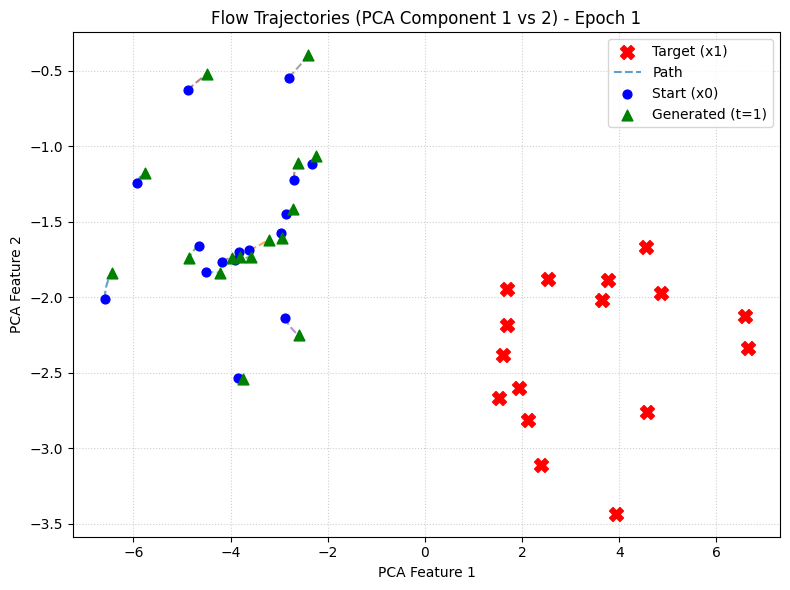

Epoch 2/100, Train Loss: 3.7407
Epoch 3/100, Train Loss: 3.7408
Epoch 4/100, Train Loss: 3.5934
Epoch 5/100, Train Loss: 3.5708
Epoch 6/100, Train Loss: 3.4733


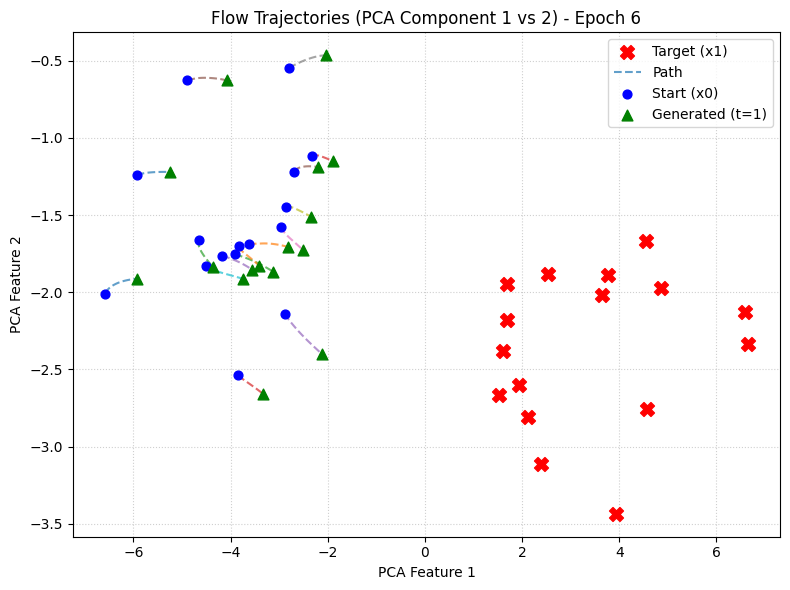

Epoch 7/100, Train Loss: 3.4268
Epoch 8/100, Train Loss: 3.3482
Epoch 9/100, Train Loss: 3.2885
Epoch 10/100, Train Loss: 3.1998
Epoch 11/100, Train Loss: 2.9956


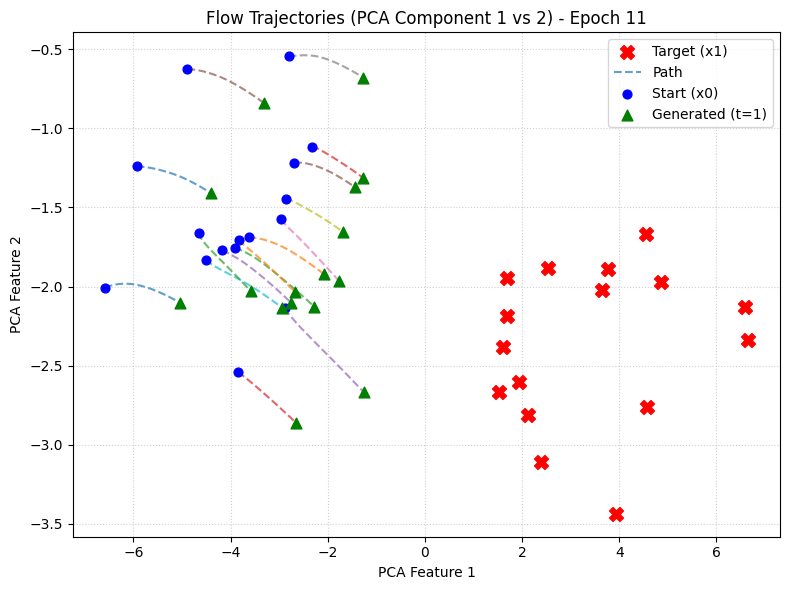

Epoch 12/100, Train Loss: 2.9930
Epoch 13/100, Train Loss: 2.8188
Epoch 14/100, Train Loss: 2.6830
Epoch 15/100, Train Loss: 2.6341
Epoch 16/100, Train Loss: 2.4768


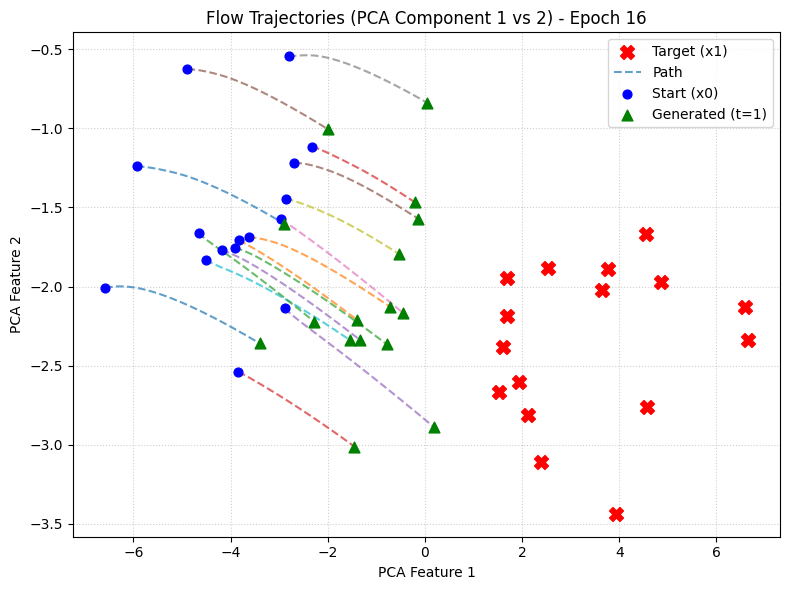

Epoch 17/100, Train Loss: 2.3921
Epoch 18/100, Train Loss: 2.3401
Epoch 19/100, Train Loss: 2.2214
Epoch 20/100, Train Loss: 2.1879
Epoch 21/100, Train Loss: 2.1175


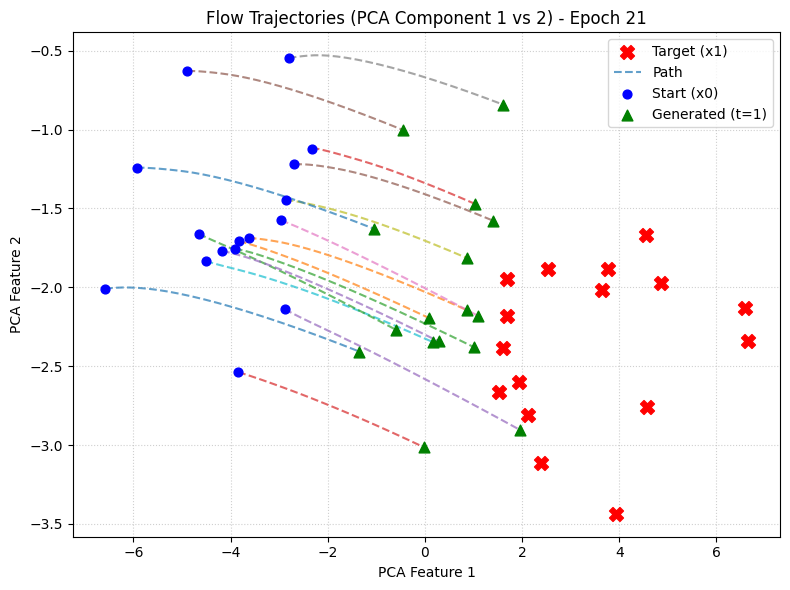

Epoch 22/100, Train Loss: 2.0957
Epoch 23/100, Train Loss: 2.0582
Epoch 24/100, Train Loss: 2.0726
Epoch 25/100, Train Loss: 2.0088
Epoch 26/100, Train Loss: 2.0185


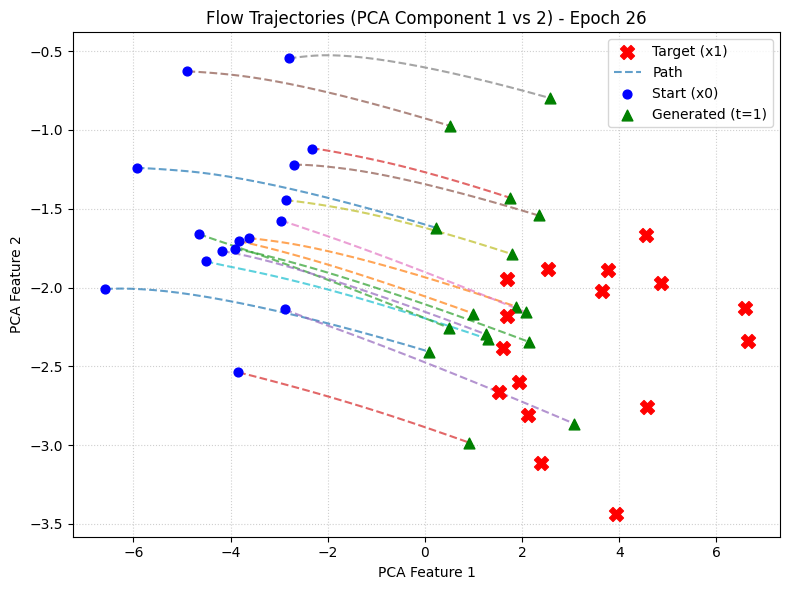

Epoch 27/100, Train Loss: 1.9946
Epoch 28/100, Train Loss: 1.9994
Epoch 29/100, Train Loss: 1.9202
Epoch 30/100, Train Loss: 1.9250
Epoch 31/100, Train Loss: 1.9838


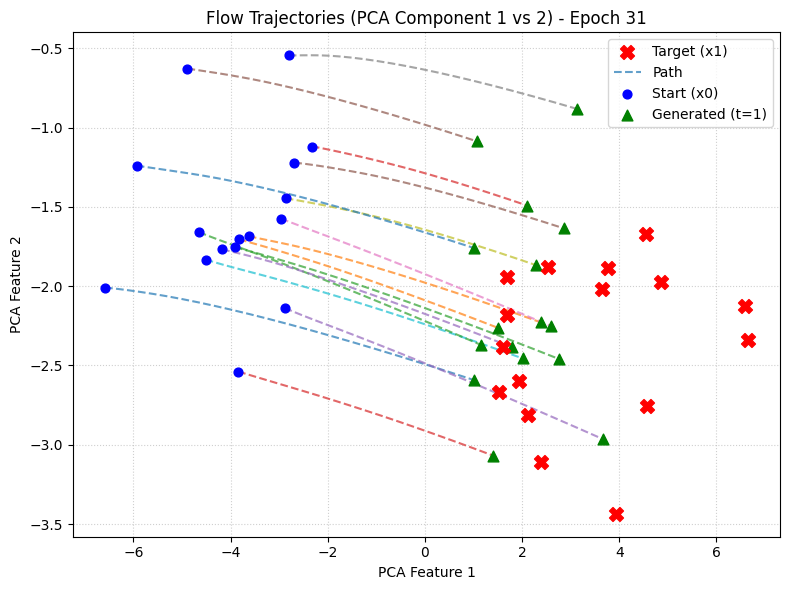

Epoch 32/100, Train Loss: 1.9506
Epoch 33/100, Train Loss: 1.9127
Epoch 34/100, Train Loss: 1.9444
Epoch 35/100, Train Loss: 1.8837
Epoch 36/100, Train Loss: 1.9129


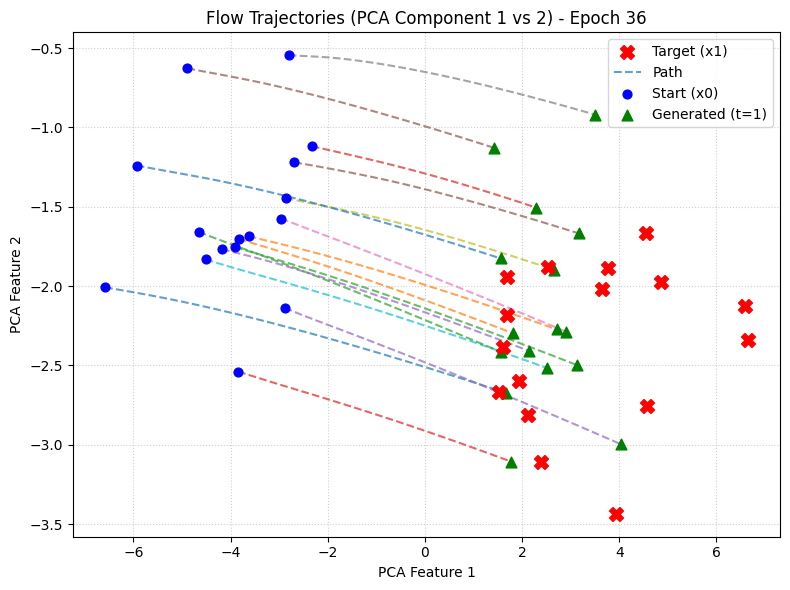

Epoch 37/100, Train Loss: 1.9049
Epoch 38/100, Train Loss: 1.8413
Epoch 39/100, Train Loss: 1.8577
Epoch 40/100, Train Loss: 1.8756
Epoch 41/100, Train Loss: 1.8593


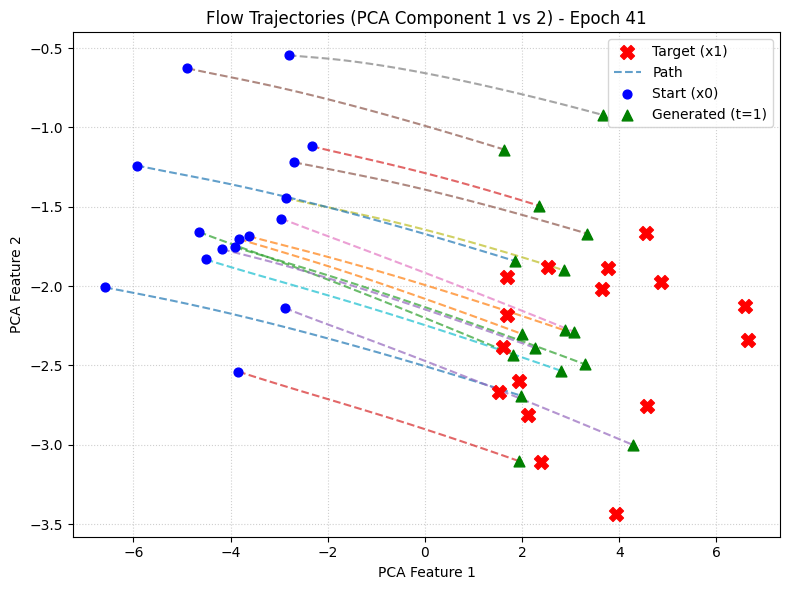

Epoch 42/100, Train Loss: 1.8715
Epoch 43/100, Train Loss: 1.8664
Epoch 44/100, Train Loss: 1.8508
Epoch 45/100, Train Loss: 1.8336
Epoch 46/100, Train Loss: 1.8124


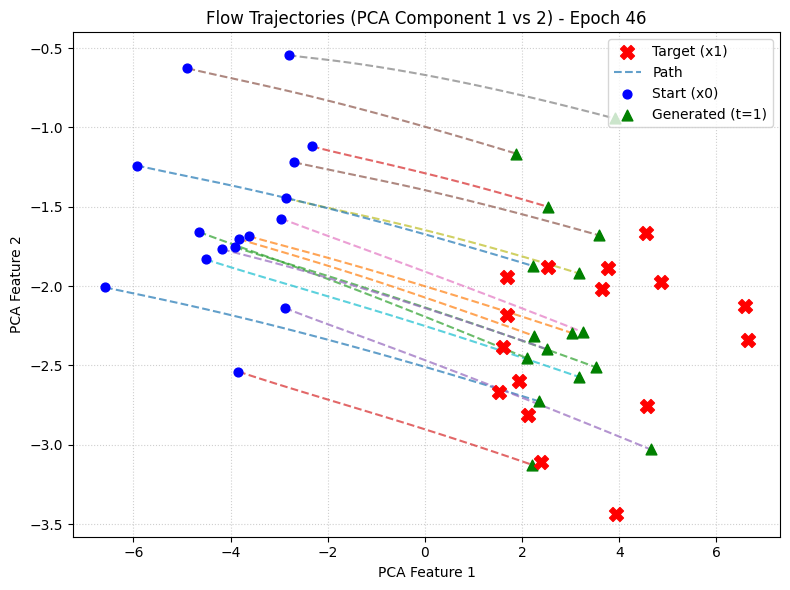

Epoch 47/100, Train Loss: 1.8302
Epoch 48/100, Train Loss: 1.8382
Epoch 49/100, Train Loss: 1.8323
Epoch 50/100, Train Loss: 1.8485
Epoch 51/100, Train Loss: 1.8539


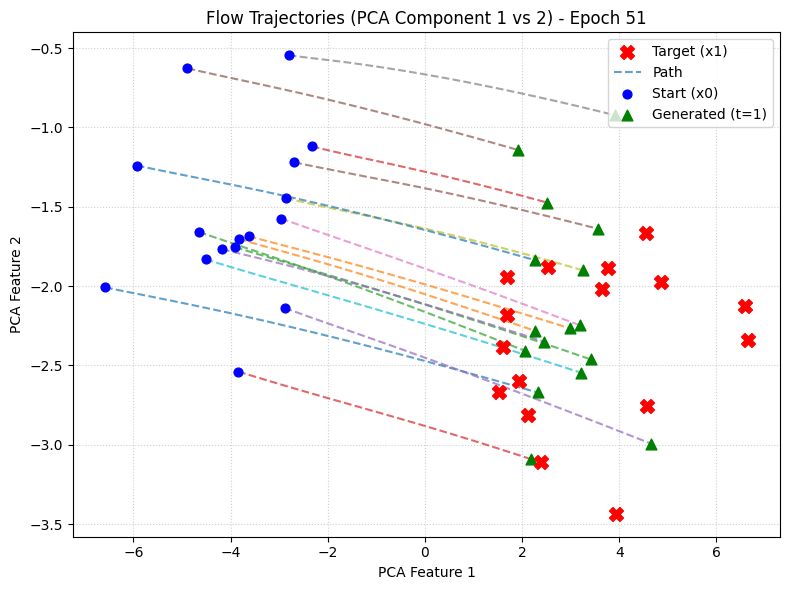

Epoch 52/100, Train Loss: 1.8174
Epoch 53/100, Train Loss: 1.8135
Epoch 54/100, Train Loss: 1.8276
Epoch 55/100, Train Loss: 1.8426
Epoch 56/100, Train Loss: 1.8041


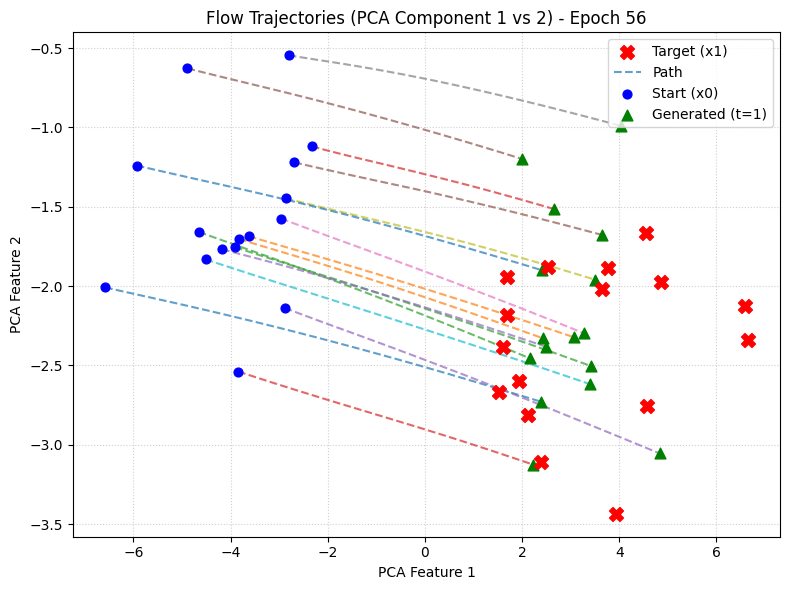

Epoch 57/100, Train Loss: 1.8125
Epoch 58/100, Train Loss: 1.8093
Epoch 59/100, Train Loss: 1.8157
Epoch 60/100, Train Loss: 1.7982
Epoch 61/100, Train Loss: 1.8190


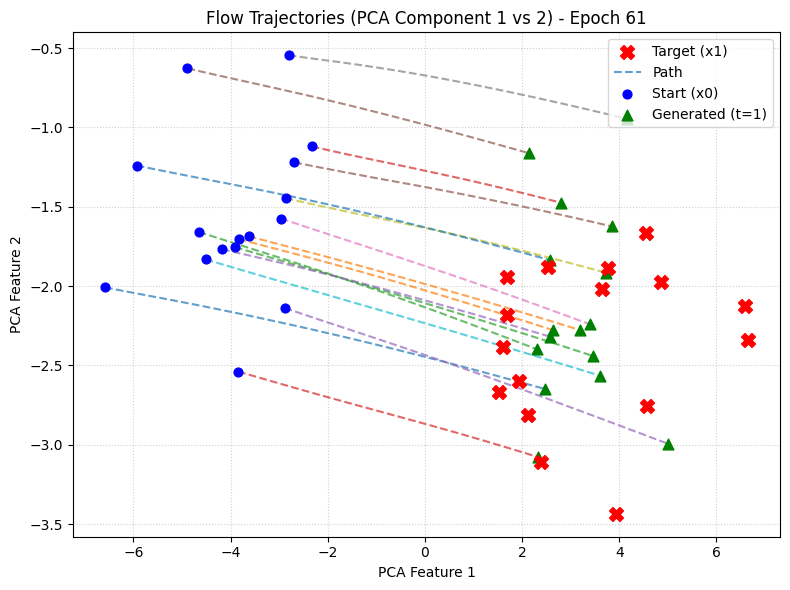

Epoch 62/100, Train Loss: 1.7975
Epoch 63/100, Train Loss: 1.7907
Epoch 64/100, Train Loss: 1.7874
Epoch 65/100, Train Loss: 1.8183
Epoch 66/100, Train Loss: 1.7764


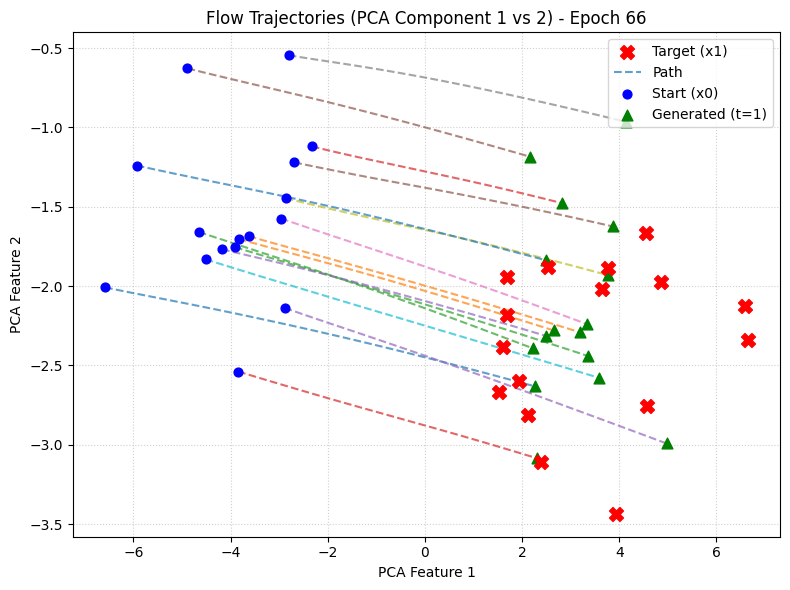

Epoch 67/100, Train Loss: 1.8286
Epoch 68/100, Train Loss: 1.7819
Epoch 69/100, Train Loss: 1.7816
Epoch 70/100, Train Loss: 1.7850
Epoch 71/100, Train Loss: 1.7845


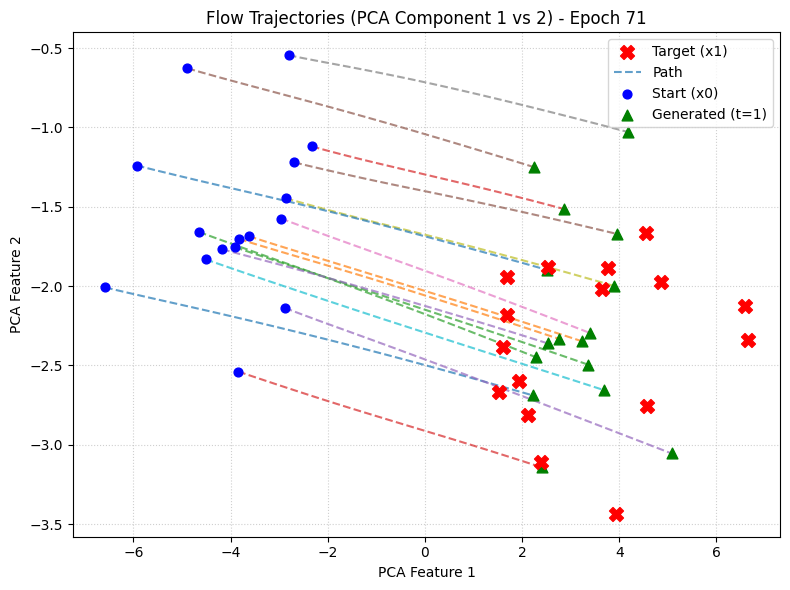

Epoch 72/100, Train Loss: 1.7665
Epoch 73/100, Train Loss: 1.7500
Epoch 74/100, Train Loss: 1.7766
Epoch 75/100, Train Loss: 1.8028
Epoch 76/100, Train Loss: 1.8081


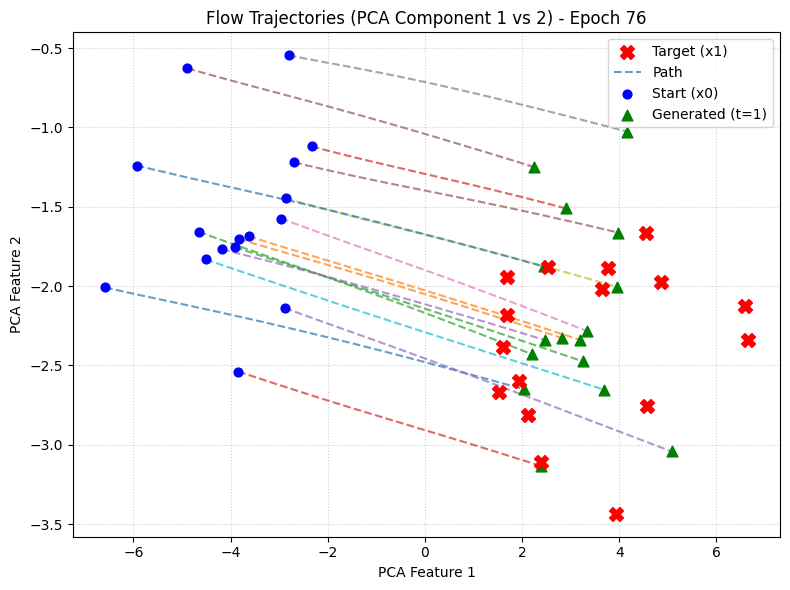

Epoch 77/100, Train Loss: 1.7628
Epoch 78/100, Train Loss: 1.7955
Epoch 79/100, Train Loss: 1.7827
Epoch 80/100, Train Loss: 1.8012
Epoch 81/100, Train Loss: 1.7828


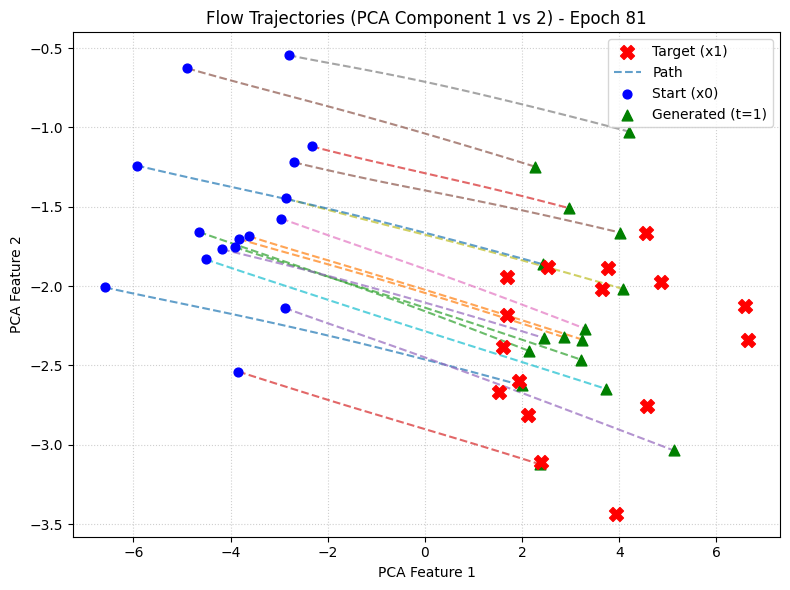

Epoch 82/100, Train Loss: 1.7955
Epoch 83/100, Train Loss: 1.7273
Epoch 84/100, Train Loss: 1.7629
Epoch 85/100, Train Loss: 1.7373
Epoch 86/100, Train Loss: 1.7720


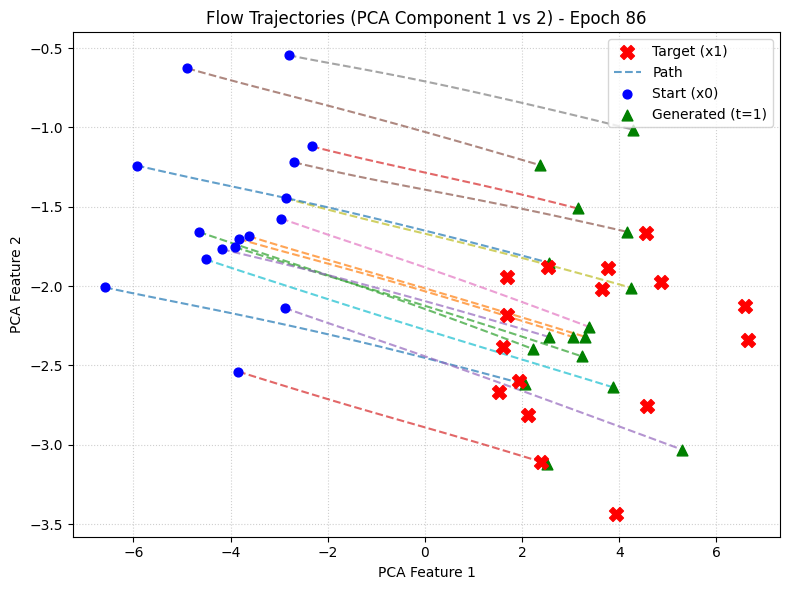

Epoch 87/100, Train Loss: 1.7613
Epoch 88/100, Train Loss: 1.7888
Epoch 89/100, Train Loss: 1.7798
Epoch 90/100, Train Loss: 1.7963
Epoch 91/100, Train Loss: 1.7975


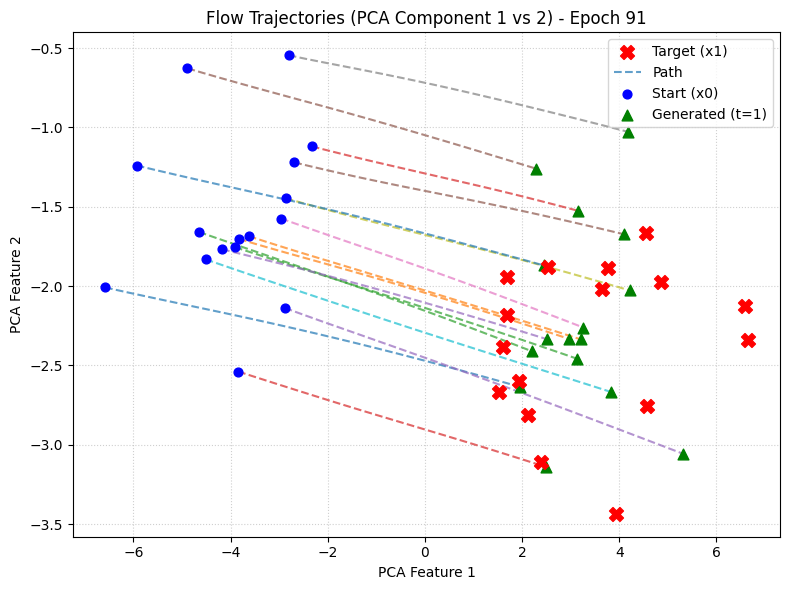

Epoch 92/100, Train Loss: 1.7691
Epoch 93/100, Train Loss: 1.7729
Epoch 94/100, Train Loss: 1.7701
Epoch 95/100, Train Loss: 1.7758
Epoch 96/100, Train Loss: 1.7505


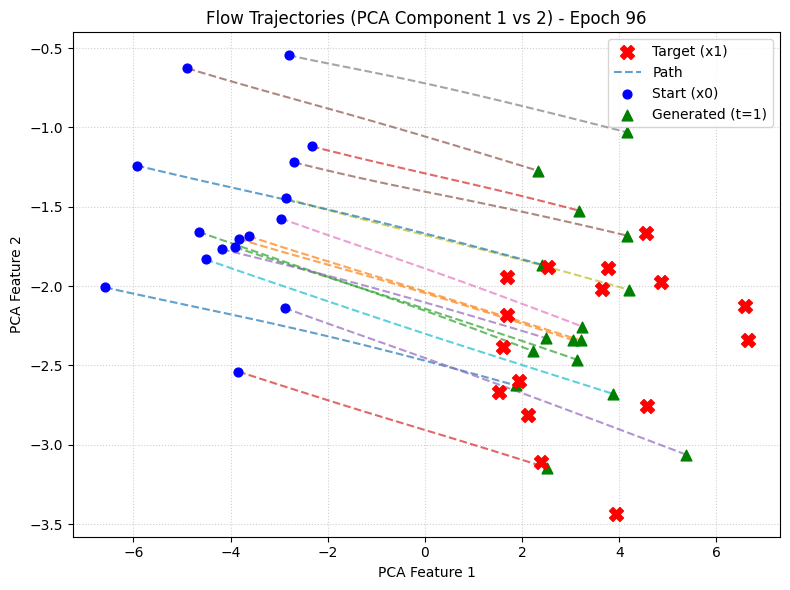

Epoch 97/100, Train Loss: 1.7356
Epoch 98/100, Train Loss: 1.7483
Epoch 99/100, Train Loss: 1.7579
Epoch 100/100, Train Loss: 1.7492


In [81]:
main()

Sample

In [ ]:
@torch.no_grad()
def sample_states(model, num_samples, steps):
  if num_samples < 1 or steps < 1:
    raise ValueError("num_samples and steps must be greater than 0")
  model.eval()
  device = next(model.parameters()).device
  x0 = sample_noise(num_samples).to(device)
  t = torch.linspace(1, 0, steps + 1, device=device)


In [ ]:
torch.manual_seed(SEED + 1)
samples, trajectory = sample_images()